# Task c - Part 1

Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies your system is using to balance the renewable generation at different time scales (intraday, seasonal, etc.)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

## Technologies data and costs
The technology cost and performance assumptions are taken from the PyPSA Technology Data database (PyPSA/technology-data, v0.11.0). 

This database compiles assumptions and projections for a wide range of energy system technologies for different years. The data can be imported into Python and loaded into a pandas.DataFrame. 

In [2]:
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [3]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # Assign the natural gas fuel cost to the CCGT technology (fuel prices are stored under "gas" in the database)

In [4]:
#calculate annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

#calculate marginal cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

#calculate capital cost
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

technologies = ["onwind", "solar", "CCGT", "coal", "PHS"]

data = {
    "Capital cost (EUR/MW/a)": [costs.at[t, "capital_cost"] for t in technologies],
    "Marginal cost (EUR/MWh)": [costs.at[t, "marginal_cost"] for t in technologies],
}

cost_table = pd.DataFrame(data, index=technologies)

cost_table

,Capital cost (EUR/MW/a),Marginal cost (EUR/MWh)
onwind,101644.123324,1.428600
solar,51346.829820,0.010600
CCGT,104788.020783,46.803121
coal,337208.027448,30.098840
PHS,182698.734592,0.000000


## Data
For this project, time series data are required for the wind and solar capacity factors, as well as for electricity demand. The datasets used include:
-  Time series of wind capacity factors for European countries
- Time series of solar capacity factors for European countries
- Electricity demand time series

In [5]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

In [6]:
# For this project the chosen country was Spain
country = 'ESP'

# Joint capacity and dispatch optimization

In [7]:
# create an empty PyPSA network where later we will place buses, generators, loads, storage, lines
# we need a list with all hours in a year because electricty system are balanced every hour
n = pypsa.Network()

# creates a list of all hours, length = 8760 (number of hours in a year)
hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')

n.set_snapshots(hours.values) 

# a bus is a connection point where electricity is balanced (meeting point in the model)
# generators inject electricity into the bus, loads take electricity from the bus (generation=demand)
n.add("Bus", #one bus = single-region model
            "Spain electricity") # one node called Spain electricity

n.snapshots

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [8]:
# a carrier is a label for the type of technologies, it defines the categories
carriers = [
    "onwind",
    "solar",
    "coal",
    "CCGT",
    "PHS", #adding the storage technology -- pumped hydro storage
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green", "brown"], # colors that represent each carrier
)

In [9]:
# add load to the bus
# load mean electricity consumption (demand), in this case is Spain's electricity demand every hour of 2011
n.add("Load",
      "demand", #label, we can call what we want
      bus="Spain electricity",
      p_set=data_el[country].values) #p_set, fixed power consumption, the model cannot change this demand

#demand is fixed because demand is inelastic (demand does not respond to price)

In [10]:
# adding the generators, which generators exist and characteristics
# CCGT (gas turbine)
n.add(
    "Generator",
    "CCGT",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="CCGT",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=25300, # 25.3 GW
)

# coal
n.add(
    "Generator",
    "coal",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="coal",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["coal", "capital_cost"],
    marginal_cost=costs.at["coal", "marginal_cost"],
    efficiency=costs.at["coal", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=11700, # 11.7 GW
)

#capacity factor time series that are called in p_max_pu
CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Onshore wind
n.add(
        "Generator",
        "onwind",
        bus="Spain electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values, # since renewables cannot produce whenever they want, their output is limited by weather data
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

#solar capacity factor
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Solar PV
n.add(
        "Generator",
        "solar",
        bus="Spain electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

# Pumped Hydro Storage
n.add(
    "StorageUnit",
    "PHS",
    bus="Spain electricity",
    carrier="PHS",
    max_hours=6,  # storage can discharge at full power for 6 hours
    capital_cost=costs.at["PHS", "capital_cost"],
    marginal_cost=costs.at["PHS", "marginal_cost"],
    # round-trip efficiency = charging efficiency * discharging efficiency
    efficiency_store=costs.at["PHS", "efficiency"]**0.5, # charging efficiency
    efficiency_dispatch=costs.at["PHS", "efficiency"]**0.5, # discharging efficiency
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)


# CCGT and coal do not have p_max_pu because is dispatchable, which means it can run whenever needed, as long it does not exceed the installed capacity

# Model PyPSA

In [11]:
n.optimize(solver_name="highs")
# PyPS decides two things at the same time: capacity (how much technology to build) and dispatch (how much each generator produces in every hour of the year)

Index(['Spain electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 177.71it/s]
INFO:linopy.io: Writing time: 0.68s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140167 duals
Objective: 1.70e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [12]:
# optimised capacities in GW
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
CCGT      25.300000
coal       7.092316
onwind     4.342031
solar     59.782146
Name: p_nom_opt, dtype: float64

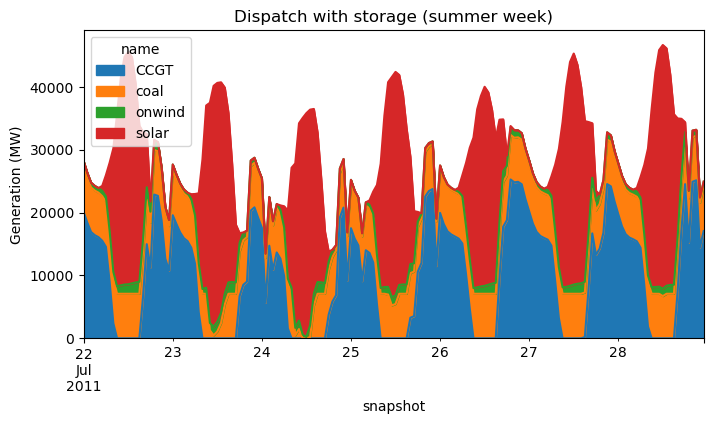

In [13]:
dispatch = n.generators_t.p

summer = dispatch.loc["2011-07-22":"2011-07-28"]

summer.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch with storage (summer week)")
plt.show()

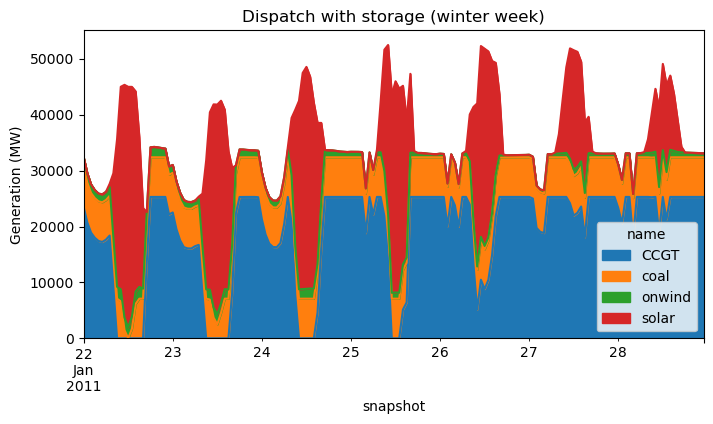

In [14]:
dispatch = n.generators_t.p

summer = dispatch.loc["2011-01-22":"2011-01-28"]

summer.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch with storage (winter week)")
plt.show()

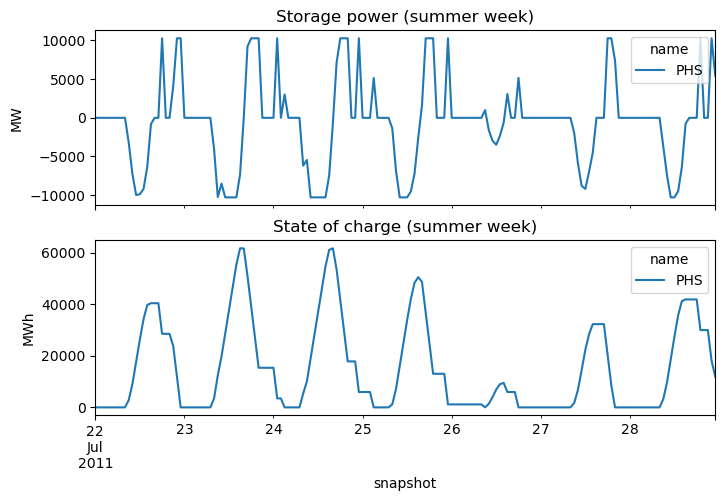

In [15]:
soc = n.storage_units_t.state_of_charge

summer_soc = soc.loc["2011-07-22":"2011-07-28"]
summer_p = n.storage_units_t.p.loc["2011-07-22":"2011-07-28"]

fig, ax = plt.subplots(2,1, figsize=(8,5), sharex=True)

summer_p.plot(ax=ax[0])
ax[0].set_title("Storage power (summer week)")
ax[0].set_ylabel("MW")

summer_soc.plot(ax=ax[1])
ax[1].set_title("State of charge (summer week)")
ax[1].set_ylabel("MWh")

plt.show()

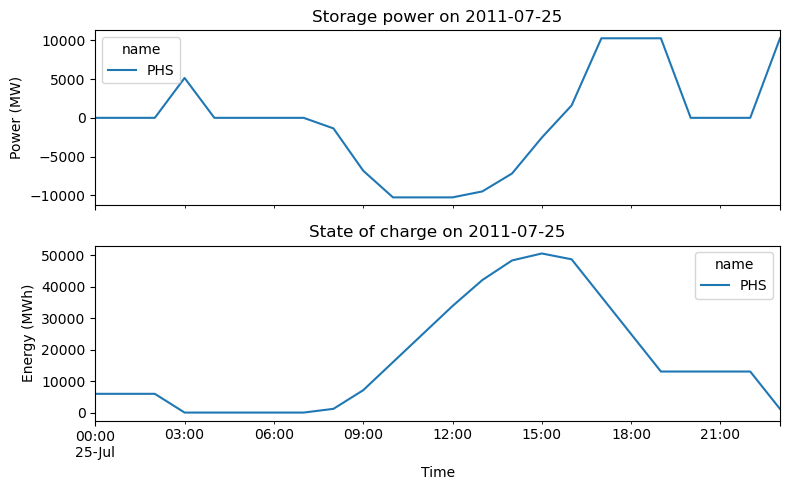

In [16]:
day = "2011-07-25"

storage_power_day = n.storage_units_t.p.loc[day]
soc_day = n.storage_units_t.state_of_charge.loc[day]

fig, ax = plt.subplots(2, 1, figsize=(8,5), sharex=True)

storage_power_day.plot(ax=ax[0])
ax[0].set_title(f"Storage power on {day}")
ax[0].set_ylabel("Power (MW)")

soc_day.plot(ax=ax[1])
ax[1].set_title(f"State of charge on {day}")
ax[1].set_ylabel("Energy (MWh)")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()